At x = 2.0:
Analytical f'(x): 9.000000
Numerical f'(x):  9.000000


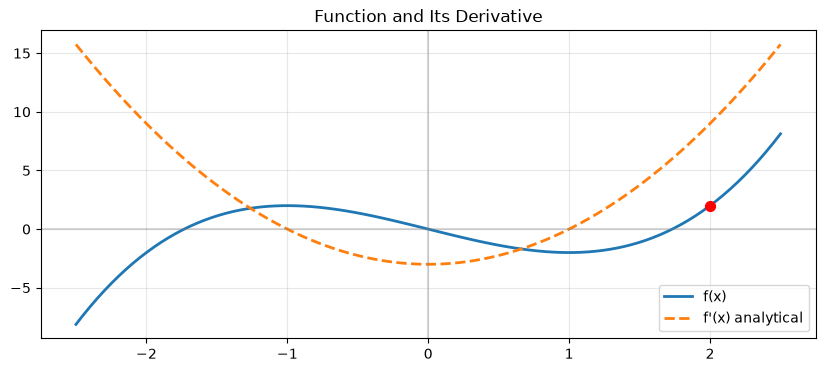

In [8]:
# DERIVATIVES, GRADIENTS & THE CHAIN RULE

# Numerical vs Analytical Derivative
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """Simple function: f(x) = x^3 - 3x"""
    return x**3 - 3*x

def df_analytical(x):
    """Analytical derivative: f'(x) = 3x^2 - 3"""
    return 3*x**2 - 3

def df_numerical(x, h=1e-5):
    """Numerical derivative using central difference: (f(x+h) - f(x-h)) / (2h)"""
    return (f(x + h) - f(x - h)) / (2*h)

# Test at a point
x_test = 2.0
print(f"At x = {x_test}:")
print(f"Analytical f'(x): {df_analytical(x_test):.6f}")
print(f"Numerical f'(x):  {df_numerical(x_test):.6f}")

# Plot function and derivative
x = np.linspace(-2.5, 2.5, 100)
plt.figure(figsize=(10, 4))
plt.plot(x, f(x), label='f(x)', linewidth=2)
plt.plot(x, df_analytical(x), label="f'(x) analytical", linestyle='--', linewidth=2)
plt.scatter([x_test], [f(x_test)], color='red', s=50, zorder=5)
plt.axhline(0, color='gray', alpha=0.3)
plt.axvline(0, color='gray', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Function and Its Derivative')
plt.show()

# Key takeaway: The derivative tells you the slope. If the slope is positive,
# increasing x increases f(x). Gradient descent moves against the slope.

In [15]:
# Gradient of a Multi-Variable Function

def g(x):
    """g(x,y) = x^2 + y^2 (a bowl shape)"""
    return x[0]**2 + x[1]**2

def grad_g_analytical(x):
    """∇g = [2x, 2y]"""
    return np.array([2*x[0], 2*x[1]])

def grad_g_numerical(x, h=1e-5):
    """Numerical gradient using central differences for each dimension"""
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[i] += h
        x_minus[i] -= h
        grad[i] = (g(x_plus) - g(x_minus)) / (2*h)
    return grad

# Test
point = np.array([1.5, -2.0])
analytical_grad = grad_g_analytical(point)
numerical_grad = grad_g_numerical(point)
print(f"At point {point}:")
print(f"Analytical gradient: {analytical_grad}")
print(f"Numerical gradient:  {numerical_grad}")
print(f"Norm of difference: {np.linalg.norm(analytical_grad - numerical_grad):.10f}")

# The gradient points in the direction of steepest ascent
# So -gradient points towards the minimum
print(f"\nSteepest ascent direction: {analytical_grad}")
print(f"Direction to minimum:       {-analytical_grad}")

# Why this matters: When training a neural network, we compute the gradient of the 
# loss with respect to every weight. Then we move each weight a tiny step opposite the 
# gradient. Repeat.

At point [ 1.5 -2. ]:
Analytical gradient: [ 3. -4.]
Numerical gradient:  [ 3. -4.]
Norm of difference: 0.0000000001

Steepest ascent direction: [ 3. -4.]
Direction to minimum:       [-3.  4.]


In [20]:
# The Chain Rule in Action

# Let's chain functions: h(x) = f(g(x))
# where g(x) = sin(x) and f(z) = z^2

def g_func(x):
    return np.sin(x)

def f_func(z):
    return z**2

def h_func(x):
    """h(x) = f(g(x)) = sin(x)^2"""
    return f_func(g_func(x))

# Analytical gradient via chain rule:
# dh/dx = f'(g(x)) * g'(x) = 2*sin(x) * cos(x)
def dh_analytical(x):
    return 2 * np.sin(x) * np.cos(x)

# Numerical verification
x_val = 1.0
num_grad = (h_func(x_val + 1e-6) - h_func(x_val - 1e-6)) / (2e-6)
ana_grad = dh_analytical(x_val)
print(f"Chain rule at x={x_val}:")
print(f"Analytical: {ana_grad:.6f}")
print(f"Numerical:  {num_grad:.6f}")

# Manually compute the intermediate gradients
z = g_func(x_val)       # sin(1.0)
dz_dx = np.cos(x_val)   # g'(x)
df_dz = 2 * z           # f'(z)
chain_result = df_dz * dz_dx
print(f"\nManual chain: df/dz * dz/dx = {df_dz:.4f} * {dz_dx:.4f} = {chain_result:.6f}")

# This is the entire secret of backpropagation. A neural network is just a long chain of 
# functions. We store intermediate values during the forward pass, then multiply gradients backward.

Chain rule at x=1.0:
Analytical: 0.909297
Numerical:  0.909297

Manual chain: df/dz * dz/dx = 1.6829 * 0.5403 = 0.909297


In [27]:
# Manual Backpropagation on a Tiny Network

# Let's do a full forward and backward pass on a mini network:
# Input: x (2D)
# Hidden layer: h = W1 @ x + b1, then ReLU
# Output: y_pred = W2 @ h + b2
# Loss: MSE = (y_pred - y_true)^2

# Define a sample data point
x = np.array([1.0, 2.0])       # input
y_true = np.array([5.0])       # target

# Initialize weights (small random)
np.random.seed(42)
W1 = np.random.randn(3, 2) * 0.1   # 3 hidden neurons, 2 inputs
b1 = np.zeros(3)
W2 = np.random.randn(1, 3) * 0.1   # 1 output, 3 hidden
b2 = np.zeros(1)

# --- Forward pass ---
z1 = W1 @ x + b1               # pre-activation (3,)
h = np.maximum(0, z1)          # ReLU (3,)
y_pred = W2 @ h + b2           # prediction (1,)
loss = np.sum((y_pred - y_true)**2)  # MSE (scalar)

print("Forward pass:")
print(f"z1 = {z1}")
print(f"h (after ReLU) = {h}")
print(f"y_pred = {y_pred}")
print(f"loss = {loss:.4f}")

# --- Backward pass (hand-derived) ---
# dL/dy_pred = 2 * (y_pred - y_true)
dL_dy_pred = 2 * (y_pred - y_true)  # shape (1,)

# dL/dW2 = dL/dy_pred * h^T (outer product)
dL_dW2 = np.outer(dL_dy_pred, h)   # (1,3)
# dL/db2 = dL/dy_pred
dL_db2 = dL_dy_pred.copy()

# dL/dh = W2^T @ dL_dy_pred
dL_dh = W2.T @ dL_dy_pred   # (3,)

# ReLU backward: gradient flows only where z1 > 0
dL_dz1 = dL_dh * (z1 > 0)   # (3,)

# dL/dW1 = dL/dz1 ⊗ x (outer product)
dL_dW1 = np.outer(dL_dz1, x)   # (3,2)
dL_db1 = dL_dz1

print("\nComputed gradients:")
print(f"dL/dW2 shape {dL_dW2.shape}:\n{dL_dW2}")
print(f"dL/dW1 shape {dL_dW1.shape}:\n{dL_dW1}")

# Manually what PyTorch's autograd does automatically. 
# The above is the same as:
# The backward pass computes the gradient of the loss with respect to every parameter by chaining local gradients.
# The chain rule is applied to each parameter, and intermediate values are stored.
# This is the essence of backpropagation.

Forward pass:
z1 = [ 0.02201856  0.36937483 -0.07024273]
h (after ReLU) = [0.02201856 0.36937483 0.        ]
y_pred = [0.03182431]
loss = 24.6828

Computed gradients:
dL/dW2 shape (1, 3):
[[-0.2187841  -3.67023806 -0.        ]]
dL/dW1 shape (3, 2):
[[-1.56916135 -3.13832269]
 [-0.76255011 -1.52510023]
 [ 0.          0.        ]]


In [ ]:
# Gradient Checking (The Universal Debugger)

def gradient_check(param_name, param_value, grad_analytical, loss_fn, h=1e-6):
    """Verify analytical gradient against numerical approximation."""
    grad_numerical = np.zeros_like(param_value)
    it = np.nditer(param_value, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old_val = param_value[idx]
        
        param_value[idx] = old_val + h
        loss_plus = loss_fn()
        param_value[idx] = old_val - h
        loss_minus = loss_fn()
        param_value[idx] = old_val  # restore
        
        grad_numerical[idx] = (loss_plus - loss_minus) / (2*h)
        it.iternext()
    
    diff = np.linalg.norm(grad_analytical - grad_numerical) / (np.linalg.norm(grad_analytical) + np.linalg.norm(grad_numerical) + 1e-8)
    print(f"{param_name}: relative error = {diff:.2e}")
    return diff

# Wrap our forward pass in a closure
def compute_loss():
    z1 = W1 @ x + b1
    h = np.maximum(0, z1)
    y_pred = W2 @ h + b2
    return np.sum((y_pred - y_true)**2)

print("Gradient checks (should be < 1e-6):")
gradient_check("W1", W1, dL_dW1, compute_loss)
gradient_check("b1", b1, dL_db1, compute_loss)
gradient_check("W2", W2, dL_dW2, compute_loss)
gradient_check("b2", b2, dL_db2, compute_loss)

# Rule of thumb: If your gradient check fails, there's a bug in your backward pass. If it passes but training doesn't work, 
# the bug is elsewhere (learning rate, initialization, etc.).

Gradient checks (should be < 1e-6):
W1: relative error = 1.21e-10
b1: relative error = 1.39e-10
W2: relative error = 3.39e-10
b2: relative error = 1.06e-10


np.float64(1.0556167105191047e-10)